In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
spark = SparkSession.builder.appName("modelling").config("spark.driver.memory", "12g").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/31 01:24:06 WARN Utils: Your hostname, aydin-khan-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlp11s0)
26/08/31 01:24:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/08/31 01:24:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# read in the yellow taxi data from parquet file
yellow_taxi_data = spark.read.parquet('cleaned_data/yellow_data.parquet')
yellow_taxi_data.show(1)

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:42:49|         138|       57.15| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


In [3]:
# prepare the yellow taxi data for training
from utils import add_stations
# aggregate to daily
print('Shape before grouping by date and location:', (yellow_taxi_data.count(), len(yellow_taxi_data.columns)))
yellow_taxi_daily_earnings = (
    yellow_taxi_data
    .withColumn("date", F.to_date("date"))
    .groupBy("date", "PULocationID", 'Borough')
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))

print('Shape before adding stations:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))
yellow_taxi_daily_earnings = add_stations(yellow_taxi_daily_earnings, spark)
print('Shape after adding stations:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))

print('Shape before reading residential data:', None)
residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)
print('Shape after reading residential data:', (residential_data.count(), len(residential_data.columns)))

print('Shape before adding residential_density:', (residential_data.count(), len(residential_data.columns)))
residential_data = residential_data.withColumn("residential_density", F.col("TotalResidentialUnits") / F.col("TotalNumBldgs"))
residential_data = residential_data.select('LocationID', 'residential_density')
print('Shape after calculating residential_density:', (residential_data.count(), len(residential_data.columns)))

print('Shape before joining with residential data:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))
training_data = yellow_taxi_daily_earnings.join(residential_data, yellow_taxi_daily_earnings.PULocationID == residential_data.LocationID, 'left').drop('LocationID')
print('Shape after joining with residential data:', (training_data.count(), len(training_data.columns)))

# drop rows where residential_density is null
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.show(2)


Shape before grouping by date and location: (96567831, 4)


Shape after grouping by date and location: (228261, 4)


Shape before adding stations: (228261, 4)


Shape after adding stations: (228261, 5)
Shape before reading residential data: None
Shape after reading residential data: (239, 7)
Shape before adding residential_density: (239, 7)
Shape after calculating residential_density: (239, 2)


Shape before joining with residential data: (228261, 5)


Shape after joining with residential data: (228261, 6)


Shape 228261 , 6


+----------+------------+---------+------------------+------------+-------------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|
+----------+------------+---------+------------------+------------+-------------------+
|2023-05-01|         165| Brooklyn|            128.86|           3| 2.4132334581772783|
|2023-05-02|          79|Manhattan| 36480.20999999998|           2| 16.148442272449604|
+----------+------------+---------+------------------+------------+-------------------+
only showing top 2 rows


In [4]:
training_data.sort('date', ascending=False).show(2)

+----------+------------+-------+------------------+------------+-------------------+
|      date|PULocationID|Borough|daily_total_amount|num_stations|residential_density|
+----------+------------+-------+------------------+------------+-------------------+
|2025-12-31|         213|  Bronx| 862.0700000000002|           0|  4.370954003407155|
|2025-12-31|         259|  Bronx|            198.18|           2|  2.006323827705524|
+----------+------------+-------+------------------+------------+-------------------+
only showing top 2 rows


In [5]:
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
print('Shape before filtering NULL residential_density:', (training_data.count(), len(training_data.columns)))
training_data = training_data.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
print('Shape after filtering NULL residential_density:', (training_data.count(), len(training_data.columns)))

# create a new column called isAirport that is 1 if PULocationID is 132, 1 or 138, else 0
print('Shape before adding isAirport:', (training_data.count(), len(training_data.columns)))
training_data = training_data.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))
print('Shape after adding isAirport:', (training_data.count(), len(training_data.columns)))

# replace null values in residential_density with 0
print('Shape before filling NULL residential_density:', (training_data.count(), len(training_data.columns)))
training_data = training_data.fillna({'residential_density': 0})
print('Shape after filling NULL residential_density:', (training_data.count(), len(training_data.columns)))


Shape before filtering NULL residential_density: (228261, 6)


Shape after filtering NULL residential_density: (219813, 6)


Shape before adding isAirport: (219813, 6)


Shape after adding isAirport: (219813, 7)


Shape before filling NULL residential_density: (219813, 7)


Shape after filling NULL residential_density: (219813, 7)


In [6]:
# prepare the fhvhv taxi data for training by extracting trip volume 
print('Shape before reading fhvhv data:', None)
fhvhv_taxi_data = spark.read.parquet('cleaned_data/fhvhv_data.parquet')
print('Shape after reading fhvhv data:', (fhvhv_taxi_data.count(), len(fhvhv_taxi_data.columns)))

print('Shape before converting date:', (fhvhv_taxi_data.count(), len(fhvhv_taxi_data.columns)))
fhvhv_taxi_data = fhvhv_taxi_data.withColumn("date", F.to_date("date"))
print('Shape after converting date:', (fhvhv_taxi_data.count(), len(fhvhv_taxi_data.columns)))

print('Shape before grouping by date and location:', (fhvhv_taxi_data.count(), len(fhvhv_taxi_data.columns)))
fhvhv_trip_volume = (
    fhvhv_taxi_data
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (fhvhv_trip_volume.count(), len(fhvhv_trip_volume.columns)))
fhvhv_taxi_data.show(2)


Shape before reading fhvhv data: None
Shape after reading fhvhv data: (821359134, 2)
Shape before converting date: (821359134, 2)
Shape after converting date: (821359134, 2)
Shape before grouping by date and location: (821359134, 2)


Shape after grouping by date and location: (320573, 3)
+----------+------------+
|      date|PULocationID|
+----------+------------+
|2023-03-01|         114|
|2023-03-01|          79|
+----------+------------+
only showing top 2 rows


In [7]:
# join the fhvhv_trip_volume to the training_data on date and PULocationID
print('Shape before joining fhvhv trip volume:', (training_data.count(), len(training_data.columns)))
training_data = training_data.join(
    fhvhv_trip_volume,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape after joining fhvhv trip volume:', (training_data.count(), len(training_data.columns)))
training_data.show()


Shape before joining fhvhv trip volume: (219813, 7)


Shape after joining fhvhv trip volume: (219556, 8)


+----------+------------+---------+------------------+------------+-------------------+---------+-----------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|isAirport|daily_trip_volume|
+----------+------------+---------+------------------+------------+-------------------+---------+-----------------+
|2023-01-01|           4|Manhattan|3635.9600000000014|           0| 24.393617021276597|        0|             2114|
|2023-01-01|          11| Brooklyn|              42.6|           0| 2.4930684874818954|        0|              703|
|2023-01-01|          24|Manhattan|3807.6100000000015|           1|  25.82941176470588|        0|              906|
|2023-01-01|          91| Brooklyn|              54.0|           0| 1.4156811499509965|        0|             3037|
|2023-01-01|         123| Brooklyn|             43.65|           1|  2.507860262008734|        0|             1721|
|2023-01-01|         137|Manhattan|20416.899999999954|           0| 35.7

In [8]:
print('Shape before feature engineering:', (training_data.count(), len(training_data.columns)))
training_data_final = training_data
print('Shape before adding log_daily_total_amount:', (training_data_final.count(), len(training_data_final.columns)))
training_data_final = training_data_final.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
print('Shape after adding log_daily_total_amount:', (training_data_final.count(), len(training_data_final.columns)))

print('Shape before adding log_daily_trip_volume:', (training_data_final.count(), len(training_data_final.columns)))
training_data_final = training_data_final.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
print('Shape after adding log_daily_trip_volume:', (training_data_final.count(), len(training_data_final.columns)))

print('Shape before adding has_station:', (training_data_final.count(), len(training_data_final.columns)))
training_data_final = training_data_final.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))
print('Shape after adding has_station:', (training_data_final.count(), len(training_data_final.columns)))

# add month and day of week columns
print('Shape before adding temporal features:', (training_data_final.count(), len(training_data_final.columns)))
training_data_final = training_data_final.withColumn("day_of_week", F.dayofweek("date"))
training_data_final = training_data_final.withColumn("month", F.month("date"))
print('Shape after adding temporal features:', (training_data_final.count(), len(training_data_final.columns)))

print('Shape before selecting features:', (training_data_final.count(), len(training_data_final.columns)))
training_data_filtered = training_data_final.drop('daily_total_amount', 'daily_trip_volume', 'date', 'num_stations', 'PULocationID')
print('Shape after selecting features:', (training_data_filtered.count(), len(training_data_filtered.columns)))


Shape before feature engineering: (219556, 8)


Shape before adding log_daily_total_amount: (219556, 8)


Shape after adding log_daily_total_amount: (219556, 9)


Shape before adding log_daily_trip_volume: (219556, 9)


Shape after adding log_daily_trip_volume: (219556, 10)


...

Shape after adding has_station: (219556, 11)


Shape before adding temporal features: (219556, 11)


Shape after adding temporal features: (219556, 13)


Shape before selecting features: (219556, 13)


Shape after selecting features: (219556, 8)


## Fetching the test data and preparing it for testing and evaluating

In [ ]:
# prepare the yellow taxi data for training
from utils import add_stations
# aggregate to daily
print('Shape before grouping by date and location:', (yellow_taxi_data.count(), len(yellow_taxi_data.columns)))
yellow_taxi_daily_earnings = (
    yellow_taxi_data
    .withColumn("date", F.to_date("date"))
    .groupBy("date", "PULocationID", 'Borough')
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))

print('Shape before adding stations:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))
yellow_taxi_daily_earnings = add_stations(yellow_taxi_daily_earnings, spark)
print('Shape after adding stations:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))

print('Shape before reading residential data:', None)
residential_data = spark.read.csv('cleaned_data/residential_data.csv', header=True, inferSchema=True)
print('Shape after reading residential data:', (residential_data.count(), len(residential_data.columns)))

print('Shape before adding residential_density:', (residential_data.count(), len(residential_data.columns)))
residential_data = residential_data.withColumn("residential_density", F.col("TotalResidentialUnits") / F.col("TotalNumBldgs"))
residential_data = residential_data.select('LocationID', 'residential_density')
print('Shape after calculating residential_density:', (residential_data.count(), len(residential_data.columns)))

print('Shape before joining with residential data:', (yellow_taxi_daily_earnings.count(), len(yellow_taxi_daily_earnings.columns)))
training_data = yellow_taxi_daily_earnings.join(residential_data, yellow_taxi_daily_earnings.PULocationID == residential_data.LocationID, 'left').drop('LocationID')
print('Shape after joining with residential data:', (training_data.count(), len(training_data.columns)))

# drop rows where residential_density is null
print('Shape', training_data.count(), ',', len(training_data.columns))
training_data.sort('date', ascending=False)
training_data.show(2)


Shape before grouping by date and location: (96567831, 4)


Shape after grouping by date and location: (228261, 4)


Shape before adding stations: (228261, 4)


Shape after adding stations: (228261, 5)
Shape before reading residential data: None
Shape after reading residential data: (239, 7)
Shape before adding residential_density: (239, 7)
Shape after calculating residential_density: (239, 2)


Shape before joining with residential data: (228261, 5)


Shape after joining with residential data: (228261, 6)


Shape 228261 , 6


+----------+------------+---------+------------------+------------+-------------------+
|      date|PULocationID|  Borough|daily_total_amount|num_stations|residential_density|
+----------+------------+---------+------------------+------------+-------------------+
|2023-05-01|         165| Brooklyn|            128.86|           3| 2.4132334581772783|
|2023-05-02|          79|Manhattan| 36480.20999999998|           2| 16.148442272449604|
+----------+------------+---------+------------------+------------+-------------------+
only showing top 2 rows


In [11]:
print('Shape before filtering NULL residential_density:', (training_data.count(), len(training_data.columns)))
# remove all areas that have NULL residential_density except with PULocationID 1, 132 or 138
training_data = training_data.filter(~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138]))))
print('Shape after filtering NULL residential_density:', (training_data.count(), len(training_data.columns)))

print('Shape before adding isAirport:', (training_data.count(), len(training_data.columns)))
# create a new column called isAirport that is 1 if PULocationID is 132, 1 or 138, else 0
training_data = training_data.withColumn('isAirport', F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))
print('Shape after adding isAirport:', (training_data.count(), len(training_data.columns)))

# replace null values in residential_density with 0
training_data = training_data.fillna({'residential_density': 0})
print('Shape after replacing NULL values:', (training_data.count(), len(training_data.columns)))


Shape before filtering NULL residential_density: (228261, 6)


Shape after filtering NULL residential_density: (219813, 6)


Shape before adding isAirport: (219813, 6)


Shape after adding isAirport: (219813, 7)


Shape after replacing NULL values: (219813, 7)


In [12]:
# prepare the fhvhv taxi data for training by extracting trip volume 
fhvhv_taxi_data = spark.read.parquet('cleaned_data/fhvhv_data.parquet')
fhvhv_taxi_data = fhvhv_taxi_data.withColumn("date", F.to_date("date"))

print('Shape before grouping by date and location:', (fhvhv_taxi_data.count(), len(fhvhv_taxi_data.columns)))
fhvhv_trip_volume = (
    fhvhv_taxi_data
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (fhvhv_trip_volume.count(), len(fhvhv_trip_volume.columns)))
fhvhv_taxi_data.show(2)

Shape before grouping by date and location: (821359134, 2)


Shape after grouping by date and location: (320573, 3)
+----------+------------+
|      date|PULocationID|
+----------+------------+
|2023-03-01|         114|
|2023-03-01|          79|
+----------+------------+
only showing top 2 rows


In [13]:
print('Shape before joining fhvhv trip volume:', (training_data.count(), len(training_data.columns)))
# join the fhvhv_trip_volume to the training_data on date and PULocationID
training_data = training_data.join(
    fhvhv_trip_volume,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape after joining fhvhv trip volume:', (training_data.count(), len(training_data.columns)))

Shape before joining fhvhv trip volume: (219813, 7)


Shape after joining fhvhv trip volume: (219556, 8)


In [14]:
training_data_final = training_data

print('Shape before feature engineering:', (training_data_final.count(), len(training_data_final.columns)))
training_data_final = training_data_final.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
training_data_final = training_data_final.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
training_data_final = training_data_final.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))
# add month and day of week columns
training_data_final = training_data_final.withColumn("day_of_week", F.dayofweek("date"))
training_data_final = training_data_final.withColumn("month", F.month("date"))
training_data_filtered = training_data_final.drop('daily_total_amount', 'daily_trip_volume', 'date', 'num_stations', 'PULocationID')

print('Shape after feature engineering:', (training_data_filtered.count(), len(training_data_filtered.columns)))

Shape before feature engineering: (219556, 8)


Shape after feature engineering: (219556, 8)


In [15]:
# Read preprocessed test data (already filtered and cleaned)
yellow_taxi_data_2026 = spark.read.parquet("cleaned_data/yellow_taxi_2026_preprocessed")
fhvhv_data_2026 = spark.read.parquet("cleaned_data/fhvhv_2026_preprocessed")


print('Shape of yellow taxi data 2026:', (yellow_taxi_data_2026.count(), len(yellow_taxi_data_2026.columns)))
print('Shape of fhvhv data 2026:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))
# Aggregate directly without filtering
yellow_taxi_daily_earnings_2026 = (
    yellow_taxi_data_2026
    .groupBy("date", "PULocationID")
    .agg(F.sum("total_amount").alias("daily_total_amount"))
    .orderBy("date")
)
print('Shape of yellow taxi daily earnings 2026:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before grouping by date and location:', (fhvhv_data_2026.count(), len(fhvhv_data_2026.columns)))

fhvhv_daily_2026 = (
    fhvhv_data_2026
    .groupBy("date", "PULocationID")
    .agg(F.count("*").alias("daily_trip_volume"))
    .orderBy("date")
)
print('Shape after grouping by date and location:', (fhvhv_daily_2026.count(), len(fhvhv_daily_2026.columns)))


print('Shape before adding stations:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add stations information
yellow_taxi_daily_earnings_2026 = add_stations(yellow_taxi_daily_earnings_2026, spark)
print('Shape after adding stations:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before adding residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add residential density by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    residential_data,
    yellow_taxi_daily_earnings_2026.PULocationID == residential_data.LocationID,
    'left'
).drop('LocationID')
print('Shape after adding residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before adding isAirport:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add isAirport column
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.withColumn('isAirport', 
    F.when(F.col('PULocationID').isin([132, 1, 138]), 1).otherwise(0))

print('Shape after adding isAirport:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before filtering NULL residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Remove all areas that have NULL residential_density except airports (1, 132, 138)
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.filter(
    ~((F.col('residential_density').isNull()) & (~F.col('PULocationID').isin([1, 132, 138])))
)
print('Shape after filtering NULL residential_density:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

# Replace null values in residential_density with 0
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.fillna({'residential_density': 0})

print('Shape before adding Borough column:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Add the Borough column by using training_data as a lookup
yellow_taxi_daily_earnings_2026 = yellow_taxi_daily_earnings_2026.join(
    training_data_final.select('PULocationID', 'Borough').distinct(),
    on='PULocationID',
    how='left'
)
print('Shape after adding Borough column:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))

print('Shape before joining with trip volume data:', (yellow_taxi_daily_earnings_2026.count(), len(yellow_taxi_daily_earnings_2026.columns)))
# Join with trip volume data
test_data = yellow_taxi_daily_earnings_2026.join(
    fhvhv_daily_2026,
    on=["date", "PULocationID"],
    how='inner'
)
print('Shape after joining with trip volume data:', (test_data.count(), len(test_data.columns)))

print('Shape before feature engineering:', (test_data.count(), len(test_data.columns)))
# Add log columns
test_data = test_data.withColumn("log_daily_total_amount", F.log1p("daily_total_amount"))
test_data = test_data.withColumn("log_daily_trip_volume", F.log1p("daily_trip_volume"))
test_data = test_data.withColumn("has_station", F.when(F.col("num_stations") > 0, 1).otherwise(0))

# Add temporal features
test_data = test_data.withColumn("day_of_week", F.dayofweek("date"))
test_data = test_data.withColumn("month", F.month("date"))

# Drop unnecessary columns (keep only features and target)
test_data = test_data.drop('daily_total_amount', 'daily_trip_volume', 'num_stations', 'PULocationID')

print('Shape after feature engineering:', (test_data.count(), len(test_data.columns)))

print(f"Test data shape: {test_data.count()} rows, {len(test_data.columns)} columns")
test_data.show(2)

Shape of yellow taxi data 2026: (12259044, 3)
Shape of fhvhv data 2026: (98984876, 3)
Shape of yellow taxi daily earnings 2026: (33960, 3)
Shape before grouping by date and location: (98984876, 3)


Shape after grouping by date and location: (39035, 3)
Shape before adding stations: (33960, 3)
Shape after adding stations: (33960, 4)
Shape before adding residential_density: (33960, 4)
Shape after adding residential_density: (33960, 5)
Shape before adding isAirport: (33960, 5)
Shape after adding isAirport: (33960, 6)
Shape before filtering NULL residential_density: (33960, 6)
Shape after filtering NULL residential_density: (32444, 6)
Shape before adding Borough column: (32444, 6)


Shape after adding Borough column: (32444, 7)


Shape before joining with trip volume data: (32444, 7)


Shape after joining with trip volume data: (32418, 8)


Shape before feature engineering: (32418, 8)


Shape after feature engineering: (32418, 9)


Test data shape: 32418 rows, 9 columns


+----------+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
|      date|residential_density|isAirport| Borough|log_daily_total_amount|log_daily_trip_volume|has_station|day_of_week|month|
+----------+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
|2026-04-06|  2.588637266587207|        0|Brooklyn|     5.648974238161206|    7.850103545175582|          1|          2|    4|
|2026-04-05|  2.588637266587207|        0|Brooklyn|     4.948759890378168|    7.820840879907344|          1|          1|    4|
+----------+-------------------+---------+--------+----------------------+---------------------+-----------+-----------+-----+
only showing top 2 rows


# Model 1: Random Forest Regression
The steps in this section are:
- Perform hyperparameter tuning to obtain a random forest regressor that maximises <b>mean squared error</b>. 
- Observe a visual time-series-style forecast of the 2026 yellow taxi earnings.
- Interpret the model and see what features it regards as most important.
- Diagnose the residuals and see if the model has missed any systematic patterns in the test data.

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
# Prepare training data
X_train = training_data_filtered.toPandas()
y_train = X_train.pop('log_daily_total_amount')

# Prepare test data
X_test = test_data.toPandas()
X_test.drop('date', inplace=True, axis=1)
y_test = X_test.pop('log_daily_total_amount')

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# Define numeric and categorical features
numeric_features = ['has_station', 'residential_density', 'isAirport', 'log_daily_trip_volume', 
                    'day_of_week', 'month']
categorical_features = ['Borough']

# Create preprocessing pipeline with one-hot encoding for Borough
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# Create full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full dataset
pipeline.fit(X_train, y_train)

# Cross-validation on training data
print("\nCross-validation (5-fold):")
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"  CV R² scores: {cv_scores}")
print(f"  Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Evaluate on test data
print("TEST SET EVALUATION")

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nRMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

Training set size: 219556
Test set size: 32418

Cross-validation (5-fold):
  CV R² scores: [0.94650855 0.94579897 0.94670644 0.94655064 0.94617864]
  Mean CV R²: 0.9463 ± 0.0003
TEST SET EVALUATION

RMSE: 0.9322
R²: 0.8054
MAE: 0.7231


In [17]:
# print parameters of the trained model
rf_model = pipeline.named_steps['regressor']
print("\nRandom Forest Model Parameters:")
print(rf_model.get_params())


Random Forest Model Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 20, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


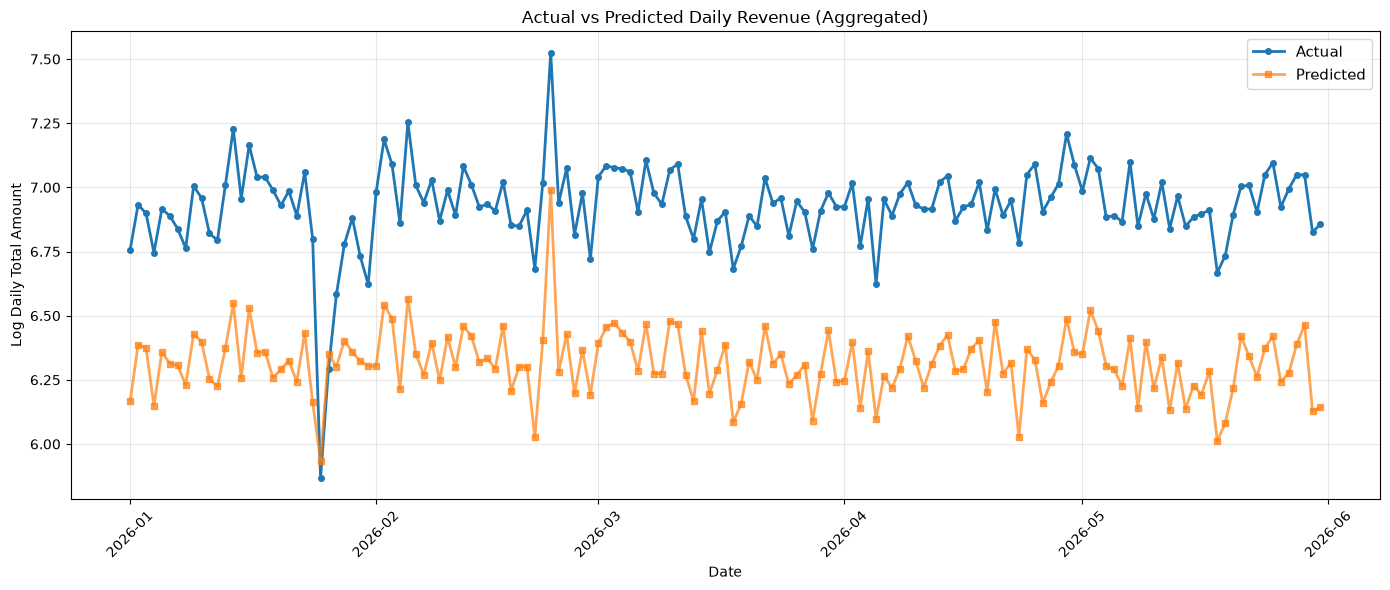

In [18]:
# Add predictions and actual values to test data
X_test_with_pred = pd.DataFrame({
    "date": test_data.select("date").toPandas()["date"],
    "y_actual": y_test.values,
    "y_pred": y_pred
})

# Aggregate by date
daily_actual = X_test_with_pred.groupby('date')['y_actual'].mean()
daily_pred = X_test_with_pred.groupby('date')['y_pred'].mean()

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_actual.index, daily_actual.values, label='Actual', linewidth=2, marker='o', markersize=4)
ax.plot(daily_pred.index, daily_pred.values, label='Predicted', linewidth=2, marker='s', markersize=4, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Log Daily Total Amount')
ax.set_title('Actual vs Predicted Daily Revenue (Aggregated)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interpretations and model diagnostics

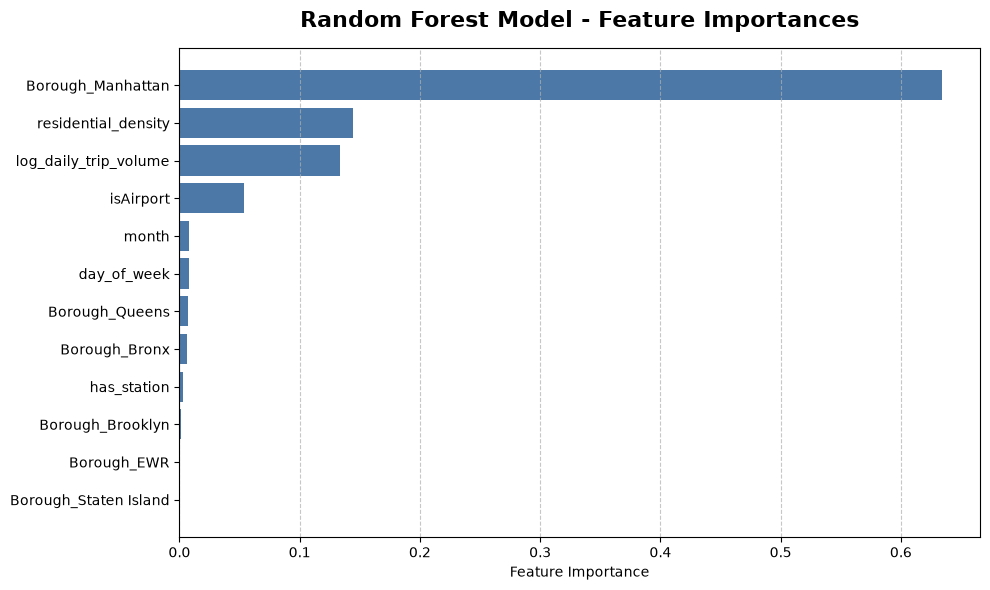

In [19]:
# Feature importance
rf_model = pipeline.named_steps['regressor']
feature_importances = rf_model.feature_importances_

# Get feature names after preprocessing
feature_names = numeric_features.copy()
# Add borough one-hot encoded names
encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat']
borough_names = [f"Borough_{b}" for b in encoder.categories_[0]]
feature_names.extend(borough_names)

# Create DataFrame and sort
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
importance_df_sorted = importance_df.sort_values('Importance')
plt.barh(importance_df_sorted['Feature'], importance_df_sorted['Importance'], color='#4C78A8')
plt.xlabel('Feature Importance')
plt.title('Random Forest Model - Feature Importances', fontsize=16, fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

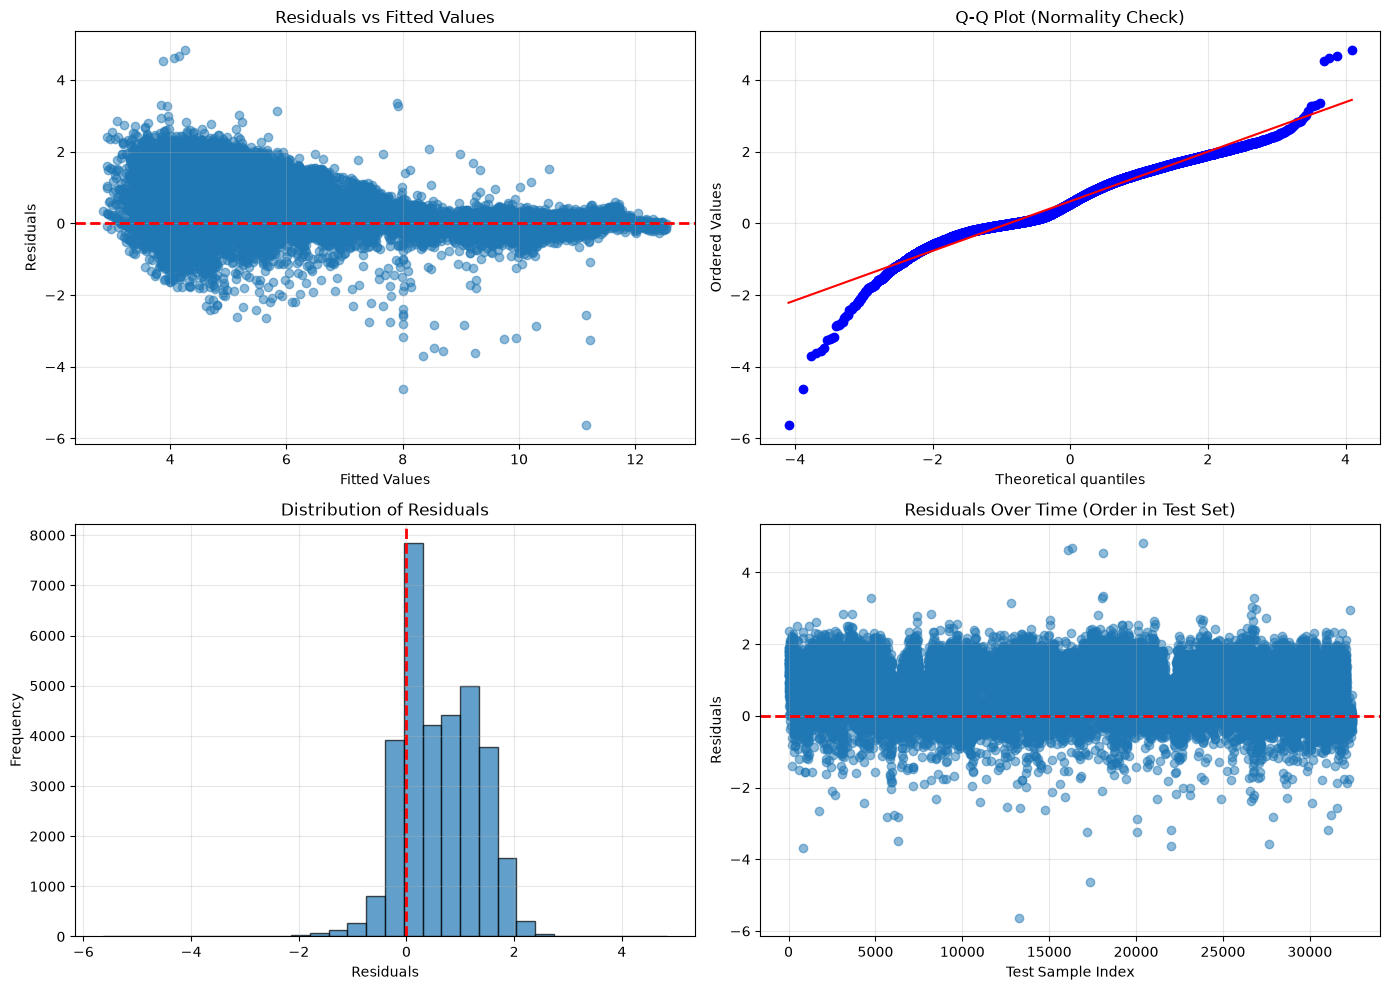

In [20]:
from scipy import stats

# Get predictions on test data
y_pred = pipeline.predict(X_test)
residuals = y_test.values - y_pred

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Fitted Values
ax1 = axes[0, 0]
ax1.scatter(y_pred, residuals, alpha=0.5)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q Plot (check normality)
ax2 = axes[0, 1]
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot (Normality Check)')
ax2.grid(True, alpha=0.3)

# Plot 3: Histogram of residuals
ax3 = axes[1, 0]
ax3.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
ax3.set_xlabel('Residuals')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Residuals')
ax3.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax3.grid(True, alpha=0.3)

# Plot 4: Residuals over time (order in test set)
ax4 = axes[1, 1]
ax4.scatter(range(len(residuals)), residuals, alpha=0.5)
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Test Sample Index')
ax4.set_ylabel('Residuals')
ax4.set_title('Residuals Over Time (Order in Test Set)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model 2: OLS Regression with Fourier Features
A linear regression model was fitted using Fourier features to capture seasonal patterns in the data. The Fourier features consist of three pairs of sine and cosine terms, allowing the model to represent periodic variation across the year. Numerical features were standardised using StandardScaler, while the categorical Borough variable was converted into numerical features using one-hot encoding.

The preprocessing steps were fitted using the training data and then applied to both the training and test sets to prevent data leakage. An Ordinary Least Squares (OLS) regression model from `statsmodels` was then fitted to the processed training data. In addition to generating predictions, the OLS model provides statistical information such as coefficient estimates, standard errors, p-values, and 95% confidence intervals, which can be used to assess the significance and uncertainty of the model coefficients.

The model was evaluated on the test set using $R^2$, RMSE, and MAE. 

In [21]:
training_data_final_copy = training_data_final
training_data_final_copy = training_data_final_copy.drop('PULocationID', 'daily_total_amount', 'daily_trip_volume', 'date', 'num_stations')
X_train_gls = training_data_final_copy.toPandas()
y_train_gls = X_train_gls.pop('log_daily_total_amount')

In [22]:
# One-hot encode the Borough column
borough_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_gls_encoded = borough_encoder.fit_transform(
    X_train_gls[['Borough']]
)

# Convert encoded Borough to a DataFrame
X_train_gls_encoded_df = pd.DataFrame(
    X_train_gls_encoded,
    columns=borough_encoder.get_feature_names_out(['Borough']),
    index=X_train_gls.index
)

# Remove original Borough column and concatenate encoded columns
X_train_gls_final = pd.concat(
    [
        X_train_gls.drop('Borough', axis=1),
        X_train_gls_encoded_df
    ],
    axis=1
)
# drop Borough_Manhattan column to avoid multicollinearity
X_train_gls_final = X_train_gls_final.drop('Borough_Manhattan', axis=1)
X_train_gls_final.head()

,residential_density,isAirport,log_daily_trip_volume,has_station,day_of_week,month,Borough_Bronx,Borough_Brooklyn,Borough_EWR,Borough_Queens,Borough_Staten Island
0,24.393617,0,7.656810,0,1,1,0.0,0.0,0.0,0.0,0.0
1,2.493068,0,6.556778,0,1,1,0.0,1.0,0.0,0.0,0.0
2,25.829412,0,6.810142,1,1,1,0.0,0.0,0.0,0.0,0.0
3,1.415681,0,8.018955,0,1,1,0.0,1.0,0.0,0.0,0.0
4,2.507860,0,7.451242,1,1,1,0.0,1.0,0.0,0.0,0.0


In [23]:
from statsmodels.regression.linear_model import GLS
gls_model = GLS(y_train_gls, X_train_gls_final)
results = gls_model.fit()
print(results.summary())

                                   GLS Regression Results                                  
Dep. Variable:     log_daily_total_amount   R-squared (uncentered):                   0.975
Model:                                GLS   Adj. R-squared (uncentered):              0.975
Method:                     Least Squares   F-statistic:                          7.794e+05
Date:                    Mon, 31 Aug 2026   Prob (F-statistic):                        0.00
Time:                            01:35:32   Log-Likelihood:                     -3.3348e+05
No. Observations:                  219556   AIC:                                  6.670e+05
Df Residuals:                      219545   BIC:                                  6.671e+05
Df Model:                              11                                                  
Covariance Type:                nonrobust                                                  
                            coef    std err          t      P>|t|      [0.025   

In [24]:
test_data_final = test_data
test_data_final = test_data_final.drop('date')
X_test_gls = test_data_final.toPandas()
y_test_gls = X_test_gls.pop('log_daily_total_amount')
# one hot encode the Borough column in the test set using the same encoder as the training set
X_test_gls_encoded = borough_encoder.transform(
    X_test_gls[['Borough']]
)   
X_test_gls_encoded_df = pd.DataFrame(
    X_test_gls_encoded,
    columns=borough_encoder.get_feature_names_out(['Borough']),
    index=X_test_gls.index
)
X_test_gls_final = pd.concat(
    [
        X_test_gls.drop('Borough', axis=1),
        X_test_gls_encoded_df
    ],
    axis=1
)
X_test_gls_final = X_test_gls_final.drop('Borough_Manhattan', axis=1)
X_test_gls_final.head()

,residential_density,isAirport,log_daily_trip_volume,has_station,day_of_week,month,Borough_Bronx,Borough_Brooklyn,Borough_EWR,Borough_Queens,Borough_Staten Island
0,2.588637,0,7.850104,1,2,4,0.0,1.0,0.0,0.0,0.0
1,2.588637,0,7.820841,1,1,4,0.0,1.0,0.0,0.0,0.0
2,2.588637,0,7.183112,1,7,4,0.0,1.0,0.0,0.0,0.0
3,6.402491,0,7.215240,1,5,4,0.0,1.0,0.0,0.0,0.0
4,6.402491,0,7.127694,1,7,4,0.0,1.0,0.0,0.0,0.0


In [25]:
preds = results.predict(X_test_gls_final)

# print metrics: r2, rmse, mae
rmse = mean_squared_error(y_test_gls, preds)
r2 = r2_score(y_test_gls, preds)
mae = mean_absolute_error(y_test_gls, preds)
print(f"GLS Model - Test Set Evaluation:\nRMSE: {rmse:.4f}\nR²: {r2:.4f}\nMAE: {mae:.4f}")

GLS Model - Test Set Evaluation:
RMSE: 1.2906
R²: 0.7110
MAE: 0.9320


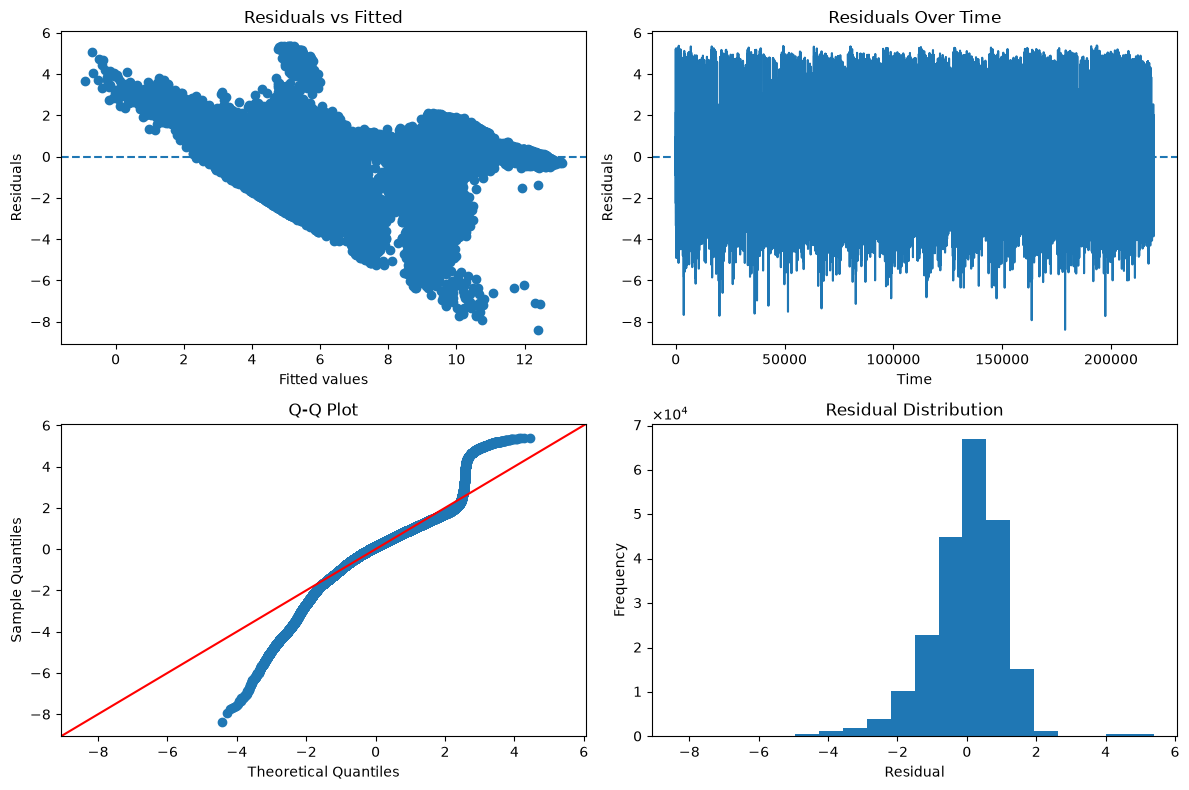

In [26]:
import statsmodels.api as sm
# import scalarformatter
from matplotlib.ticker import ScalarFormatter
Afig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals vs fitted
axes[0, 0].scatter(results.fittedvalues, results.resid)
axes[0, 0].axhline(0, linestyle="--")
axes[0, 0].set_xlabel("Fitted values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("Residuals vs Fitted")

# Residuals over time
axes[0, 1].plot(results.resid)
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals Over Time")

# Q-Q plot
sm.qqplot(results.resid, line="45", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot")

# Histogram
axes[1, 1].hist(results.resid, bins=20)
axes[1, 1].set_xlabel("Residual")
axes[1, 1].set_title("Residual Distribution")
axes[1, 1].set_ylabel("Frequency")
# add scientific notation to the y-axis of the histogram
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
axes[1, 1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()